In [1]:
# Ячейка 1: Импорт библиотек и настройка
!pip install -q datasets==3.6.0 sentence-transformers transformers matplotlib seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import math
import torch

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_recall_fscore_support
from transformers import AutoTokenizer, AutoModelForCausalLM

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Настройка отображения pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Библиотеки успешно импортированы!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 28.1 MB/s eta 0:00:00
Библиотеки успешно импортированы!


ЗАГРУЗКА ДАННЫХ CoNLL-2003


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

conll2003.py: 0.00B [00:00, ?B/s]

The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Размер тренировочного набора: 14041 примеров
Размер тестового набора: 500 примеров

Пример из тренировочного набора:
Токены: ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']
NER теги: [3, 0, 7, 0, 0, 0, 7, 0, 0]
POS теги: [22, 42, 16, 21, 35, 37, 16, 21, 7]


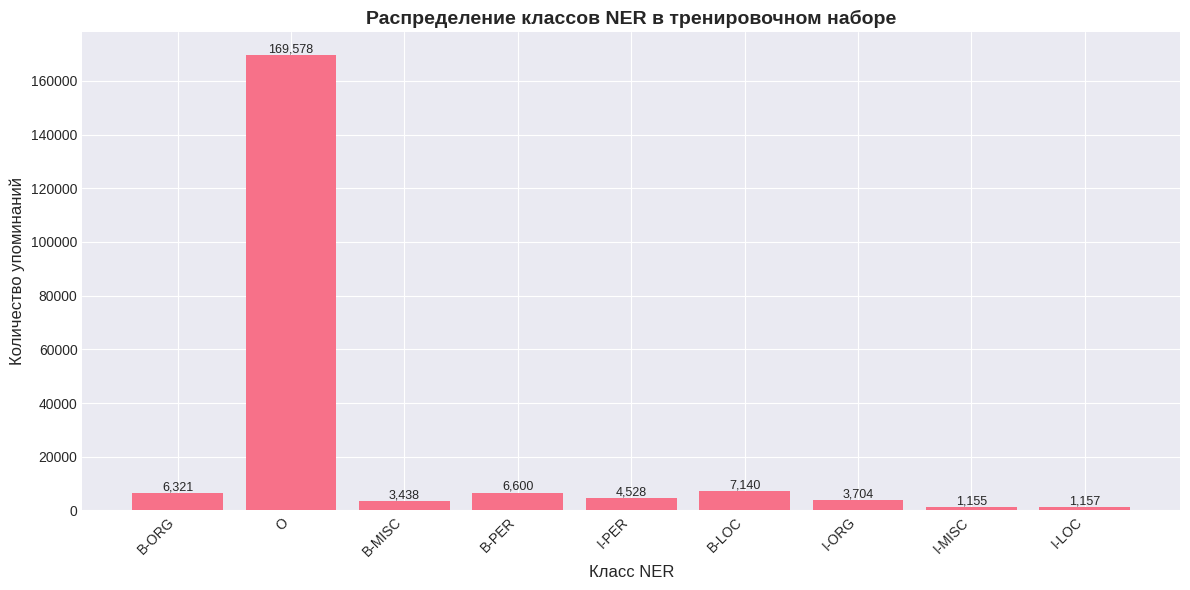

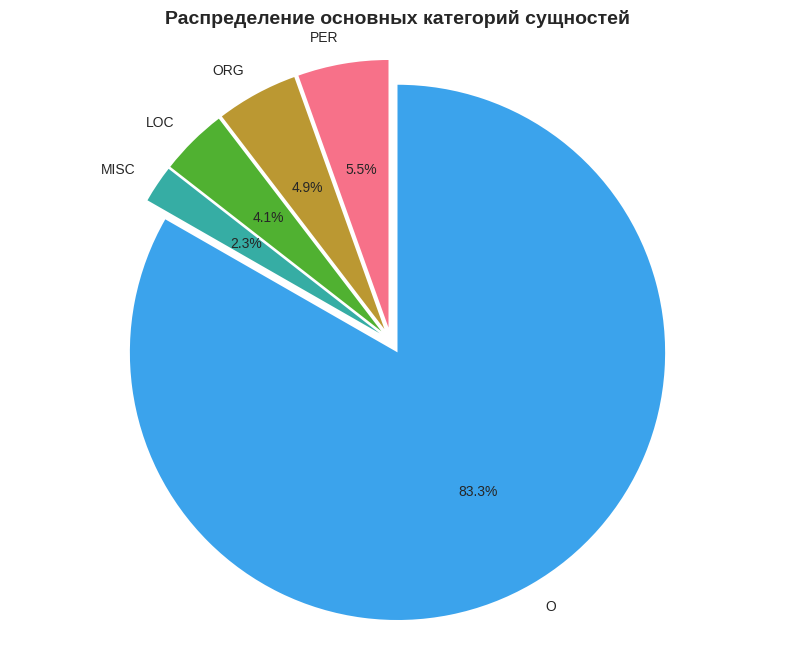

In [2]:
# Ячейка 2: Загрузка и анализ данных
print("="*50)
print("ЗАГРУЗКА ДАННЫХ CoNLL-2003")
print("="*50)

raw_dataset = load_dataset("conll2003")
train_dataset = raw_dataset["train"]
test_dataset = raw_dataset["test"].select(range(500))  # Используем подмножество для тестирования

# Вывод информации о данных
print(f"Размер тренировочного набора: {len(train_dataset)} примеров")
print(f"Размер тестового набора: {len(test_dataset)} примеров")
print(f"\nПример из тренировочного набора:")
print(f"Токены: {train_dataset[0]['tokens']}")
print(f"NER теги: {train_dataset[0]['ner_tags']}")
print(f"POS теги: {train_dataset[0]['pos_tags']}")

# Статистика по классам NER
ner_labels = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
ner_counts = defaultdict(int)

for example in train_dataset:
    for tag in example['ner_tags']:
        ner_counts[ner_labels[tag]] += 1

# Визуализация распределения классов NER
plt.figure(figsize=(12, 6))
bars = plt.bar(ner_counts.keys(), ner_counts.values())
plt.title('Распределение классов NER в тренировочном наборе', fontsize=14, fontweight='bold')
plt.xlabel('Класс NER', fontsize=12)
plt.ylabel('Количество упоминаний', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Добавление значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Круговая диаграмма для основных категорий
main_categories = {
    'PER': sum(v for k,v in ner_counts.items() if 'PER' in k),
    'ORG': sum(v for k,v in ner_counts.items() if 'ORG' in k),
    'LOC': sum(v for k,v in ner_counts.items() if 'LOC' in k),
    'MISC': sum(v for k,v in ner_counts.items() if 'MISC' in k),
    'O': ner_counts['O']
}

plt.figure(figsize=(10, 8))
plt.pie(main_categories.values(), labels=main_categories.keys(),
        autopct='%1.1f%%', startangle=90, explode=[0.05]*5)
plt.title('Распределение основных категорий сущностей', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

ПОДСЧЕТ СТАТИСТИКИ ПО СЛОВАМ
Обработка 14041 примеров...
Уникальных слов-сущностей: 7,686
Уникальных контекстных слов: 12,598
Уникальных остальных слов: 14,203


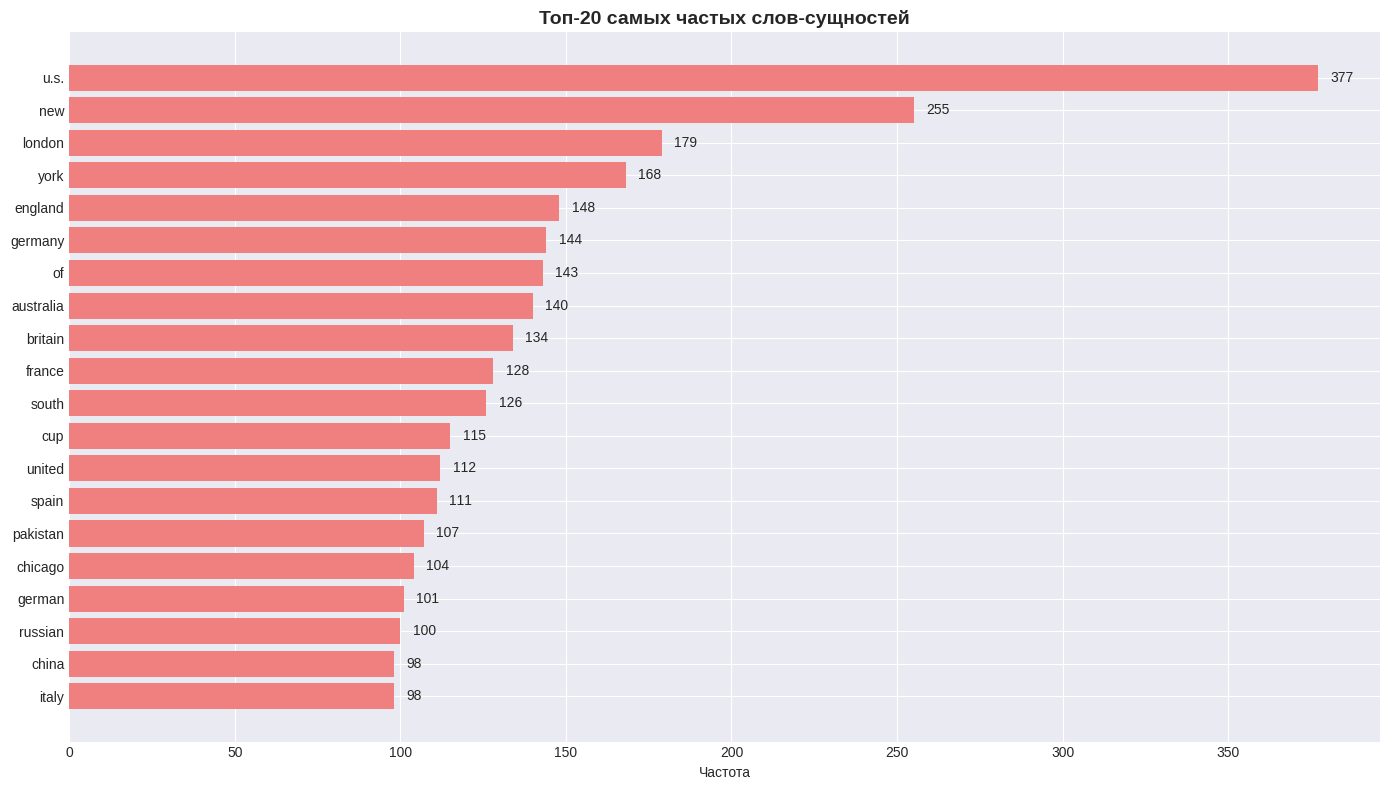

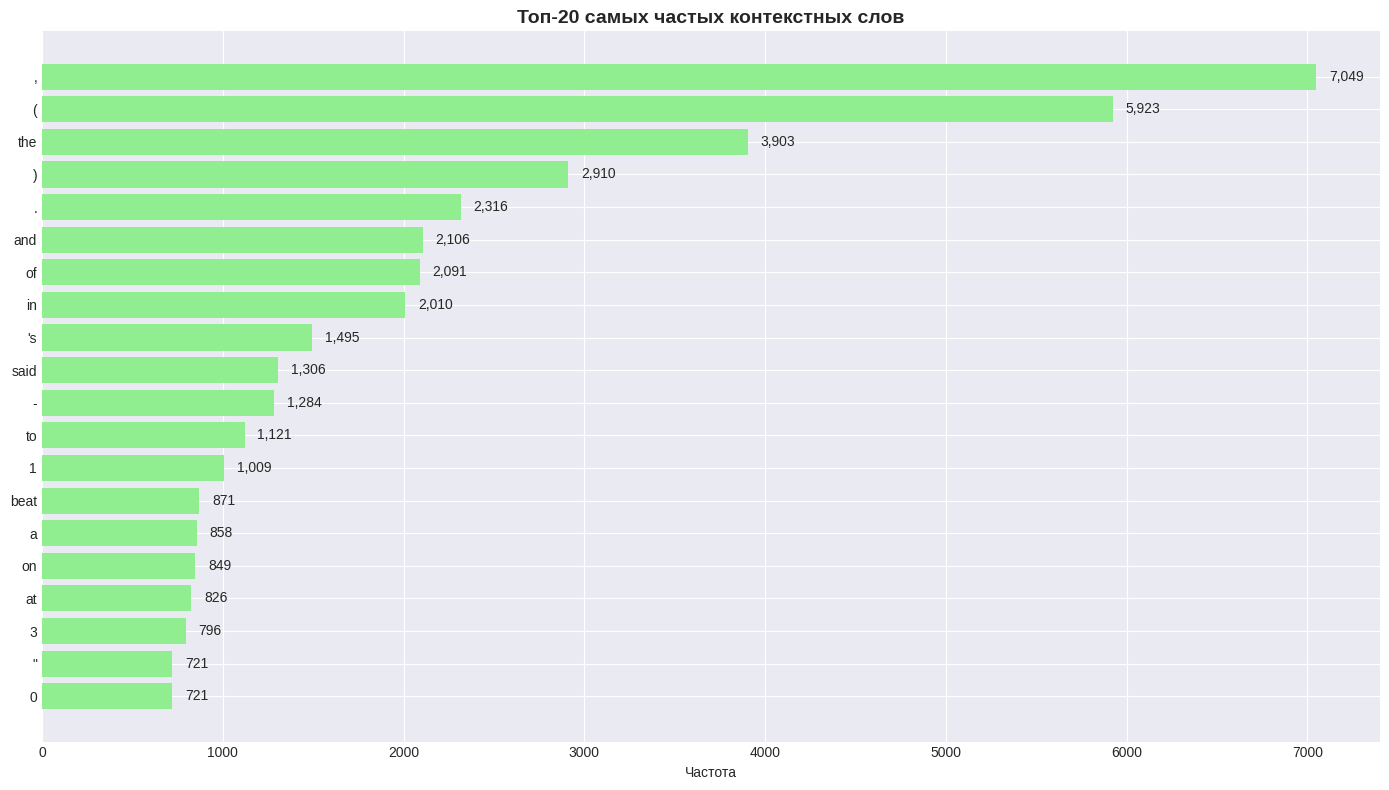


Нормализованные вероятности:
P_entity содержит 7,686 слов
P_context содержит 12,598 слов
P_other содержит 14,203 слов


In [3]:
# Ячейка 3: Подсчет статистики по словам
print("="*50)
print("ПОДСЧЕТ СТАТИСТИКИ ПО СЛОВАМ")
print("="*50)

# Словари для подсчета
entity_counts = defaultdict(int)
context_counts = defaultdict(int)
other_counts = defaultdict(int)

WINDOW_SIZE = 2  # Размер контекстного окна

print(f"Обработка {len(train_dataset)} примеров...")
for example in train_dataset:
    tokens = example["tokens"]
    tags = example["ner_tags"]

    for i, (token, tag) in enumerate(zip(tokens, tags)):
        token_lower = token.lower()

        if tag != 0:  # Если токен является сущностью
            entity_counts[token_lower] += 1

            # Подсчет контекстных слов
            start = max(0, i - WINDOW_SIZE)
            end = min(len(tokens), i + WINDOW_SIZE + 1)

            for j in range(start, end):
                if j != i:
                    context_counts[tokens[j].lower()] += 1
        else:
            other_counts[token_lower] += 1

print(f"Уникальных слов-сущностей: {len(entity_counts):,}")
print(f"Уникальных контекстных слов: {len(context_counts):,}")
print(f"Уникальных остальных слов: {len(other_counts):,}")

# Визуализация топ-20 слов по категориям
def plot_top_words(word_dict, title, color='skyblue', top_n=20):
    sorted_words = sorted(word_dict.items(), key=lambda x: x[1], reverse=True)[:top_n]
    words, counts = zip(*sorted_words) if sorted_words else ([], [])

    plt.figure(figsize=(14, 8))
    bars = plt.barh(words, counts, color=color)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Частота')
    plt.gca().invert_yaxis()  # Самые частые слова вверху

    # Добавление значений
    for bar in bars:
        width = bar.get_width()
        plt.text(width + max(counts)*0.01 if max(counts) > 0 else width + 1,
                bar.get_y() + bar.get_height()/2,
                f'{int(width):,}', va='center')

    plt.tight_layout()
    plt.show()

# Топ сущностей
plot_top_words(entity_counts, 'Топ-20 самых частых слов-сущностей', 'lightcoral')

# Топ контекстных слов
plot_top_words(context_counts, 'Топ-20 самых частых контекстных слов', 'lightgreen')

# Нормализация вероятностей
def normalize_probabilities(count_dict):
    total = sum(count_dict.values())
    return {k: v/total for k, v in count_dict.items()} if total > 0 else {}

P_entity = normalize_probabilities(entity_counts)
P_context = normalize_probabilities(context_counts)
P_other = normalize_probabilities(other_counts)

print(f"\nНормализованные вероятности:")
print(f"P_entity содержит {len(P_entity):,} слов")
print(f"P_context содержит {len(P_context):,} слов")
print(f"P_other содержит {len(P_other):,} слов")

In [4]:
# Ячейка 4: Загрузка модели эмбеддингов
print("="*50)
print("ЗАГРУЗКА МОДЕЛИ ДЛЯ ЭМБЕДДИНГОВ")
print("="*50)

# Определение устройства
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Используемое устройство: {device}")

# Загрузка модели
print("Загрузка модели SentenceTransformer...")
model_name = "all-mpnet-base-v2"
model = SentenceTransformer(model_name, device=device)

print(f"Модель '{model_name}' успешно загружена!")

# Создание эмбеддингов для тренировочных предложений
print("\nСоздание эмбеддингов для тренировочных предложений...")
train_sentences = [" ".join(example["tokens"]) for example in train_dataset]
print(f"Количество предложений для эмбеддинга: {len(train_sentences):,}")

train_embeddings = model.encode(
    train_sentences,
    show_progress_bar=True,
    convert_to_tensor=True,
    device=device,
    batch_size=32
)

print(f"Размерность эмбеддингов: {train_embeddings.shape}")
print(f"Тип данных: {train_embeddings.dtype}")

ЗАГРУЗКА МОДЕЛИ ДЛЯ ЭМБЕДДИНГОВ
Используемое устройство: cuda
Загрузка модели SentenceTransformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Модель 'all-mpnet-base-v2' успешно загружена!

Создание эмбеддингов для тренировочных предложений...
Количество предложений для эмбеддинга: 14,041


Batches:   0%|          | 0/439 [00:00<?, ?it/s]

Размерность эмбеддингов: torch.Size([14041, 768])
Тип данных: torch.float32


In [5]:
# Ячейка 5: Определение функций для работы с весами и схожестью
print("="*50)
print("ОПРЕДЕЛЕНИЕ ВСПОМОГАТЕЛЬНЫХ ФУНКЦИЙ")
print("="*50)

def calculate_token_weight(token):
    """
    Вычисляет вес токена на основе его категории
    """
    token_lower = token.lower()

    if token_lower in P_entity:
        return P_entity[token_lower]  # Высокий вес для сущностей
    elif token_lower in P_context:
        return 0.5 * P_context[token_lower]  # Средний вес для контекста
    else:
        return 0.01  # Низкий вес для остальных слов

def calculate_similarity(test_sentence):
    """
    Вычисляет схожесть между тестовым предложением и тренировочными
    с учетом весов токенов
    """
    tokens = test_sentence.split()

    # Вычисление весов для каждого токена
    weights = np.array([calculate_token_weight(token) for token in tokens])

    # Создание эмбеддинга для тестового предложения
    test_embedding = model.encode(
        [test_sentence],
        convert_to_tensor=True,
        device=device
    )[0]

    # Взвешивание эмбеддинга
    weighted_embedding = test_embedding * np.mean(weights)

    # Вычисление косинусного сходства
    similarities = torch.nn.functional.cosine_similarity(
        weighted_embedding.unsqueeze(0),
        train_embeddings
    ).cpu().numpy()

    return similarities

def retrieve_similar_examples(test_sentence, k=8):
    """
    Извлекает k наиболее похожих примеров из тренировочного набора
    """
    similarities = calculate_similarity(test_sentence)
    top_indices = np.argsort(similarities)[-k:][::-1]  # Отсортировано по убыванию

    results = []
    for idx in top_indices:
        results.append({
            'sentence': train_sentences[idx],
            'similarity': similarities[idx],
            'index': idx
        })

    return results

# Тестирование функции на примере
test_example = " ".join(test_dataset[0]["tokens"])
similar_examples = retrieve_similar_examples(test_example, k=3)

print(f"Тестовое предложение: {test_example}")
print(f"\nНаиболее похожие предложения:")
for i, example in enumerate(similar_examples, 1):
    print(f"{i}. [{example['similarity']:.4f}] {example['sentence'][:100]}...")

ОПРЕДЕЛЕНИЕ ВСПОМОГАТЕЛЬНЫХ ФУНКЦИЙ
Тестовое предложение: SOCCER - JAPAN GET LUCKY WIN , CHINA IN SURPRISE DEFEAT .

Наиболее похожие предложения:
1. [0.5525] ( Malaysia ) 11-1 10-12 11-4...
2. [0.5349] SOCCER - RESULTS OF SOUTH KOREAN PRO-SOCCER GAMES ....
3. [0.5349] SOCCER - RESULTS OF SOUTH KOREAN PRO-SOCCER GAMES ....


In [6]:
# Ячейка 6: Функция улучшения предсказаний (рефлексия)
print("="*50)
print("ФУНКЦИЯ РЕФЛЕКСИИ ДЛЯ УЛУЧШЕНИЯ ПРЕДСКАЗАНИЙ")
print("="*50)

def reflection_enhancement(sentence, predicted_entities):
    """
    Улучшает предсказанные сущности с помощью рефлексии:
    добавляет слова с высокой вероятностью быть сущностями
    """
    tokens = sentence.split()
    enhanced_prediction = set(predicted_entities)

    for token in tokens:
        token_lower = token.lower()

        # Если слово имеет высокую вероятность быть сущностью
        if token_lower in P_entity and P_entity[token_lower] > 0.001:
            if token not in enhanced_prediction:
                enhanced_prediction.add(token)
                print(f"  Добавлена сущность через рефлексию: '{token}' (P={P_entity[token_lower]:.6f})")

    return enhanced_prediction

# Тестирование функции рефлексии
test_sentence = "Apple announced new products in California yesterday"
initial_prediction = {"Apple", "California"}
print(f"Исходное предложение: {test_sentence}")
print(f"Начальное предсказание: {initial_prediction}")

enhanced = reflection_enhancement(test_sentence, initial_prediction)
print(f"Улучшенное предсказание: {enhanced}")

ФУНКЦИЯ РЕФЛЕКСИИ ДЛЯ УЛУЧШЕНИЯ ПРЕДСКАЗАНИЙ
Исходное предложение: Apple announced new products in California yesterday
Начальное предсказание: {'California', 'Apple'}
  Добавлена сущность через рефлексию: 'new' (P=0.007491)
Улучшенное предсказание: {'California', 'new', 'Apple'}


In [7]:
# Ячейка 7: Загрузка и настройка языковой модели
print("="*50)
print("ЗАГРУЗКА ЯЗЫКОВОЙ МОДЕЛИ ДЛЯ NER")
print("="*50)

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
print(f"Загрузка модели: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
llm_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if device=="cuda" else torch.float32,
    device_map="auto"
)

print(f"Модель '{model_name}' успешно загружена!")
print(f"Размер словаря: {len(tokenizer)} токенов")

def create_prompt_with_examples(sentence, demonstration_examples):
    """
    Создает промпт для языковой модели с демонстрационными примерами
    """
    prompt = """Ты экспертная система распознавания именованных сущностей (NER).
Извлеки все именованные сущности из предложения.
Сущности могут быть: персонами (PER), организациями (ORG), локациями (LOC), другими сущностями (MISC).
Верни сущности в виде списка через запятую.

Примеры:

"""

    # Добавление демонстрационных примеров
    for i, example in enumerate(demonstration_examples[:3], 1):
        # В реальном сценарии здесь должны быть размеченные примеры
        # Для демонстрации используем примеры с предположительными сущностями
        example_sentence = example['sentence']
        # Простая эвристика для демонстрации
        demo_entities = [word for word in example_sentence.split()
                        if word[0].isupper() and len(word) > 2][:3]

        prompt += f"Пример {i}:\n"
        prompt += f"Предложение: {example_sentence}\n"
        prompt += f"Сущности: {', '.join(demo_entities)}\n\n"

    prompt += f"Новое предложение:\n"
    prompt += f"Предложение: {sentence}\n"
    prompt += "Сущности:"

    return prompt

def predict_entities_with_llm(sentence, demonstration_examples):
    """
    Использует языковую модель для извлечения сущностей
    """
    prompt = create_prompt_with_examples(sentence, demonstration_examples)

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            temperature=0.1,
            pad_token_id=tokenizer.eos_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Извлечение части с сущностями
    if "Сущности:" in response:
        entities_text = response.split("Сущности:")[-1].strip()
    else:
        entities_text = response.split("Новое предложение:")[-1].strip()

    # Парсинг сущностей
    entities = [entity.strip() for entity in entities_text.split(",")
                if len(entity.strip()) > 0]

    return set(entities)

# Тестирование LLM
test_sentence = "Microsoft announced partnership with OpenAI in Seattle"
demos = retrieve_similar_examples(test_sentence, k=2)

print(f"Тестовое предложение: {test_sentence}")
print(f"\nИспользуемые демонстрационные примеры:")
for i, demo in enumerate(demos, 1):
    print(f"{i}. {demo['sentence'][:80]}...")

predicted_entities = predict_entities_with_llm(test_sentence, demos)
print(f"\nПредсказанные сущности: {predicted_entities}")

ЗАГРУЗКА ЯЗЫКОВОЙ МОДЕЛИ ДЛЯ NER
Загрузка модели: Qwen/Qwen2.5-0.5B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Модель 'Qwen/Qwen2.5-0.5B-Instruct' успешно загружена!
Размер словаря: 151665 токенов
Тестовое предложение: Microsoft announced partnership with OpenAI in Seattle

Используемые демонстрационные примеры:
1. " Microsoft sent a lot of signals that NT was going to be the answer , " Winkler...
2. NOTE - Orii Corp makes automation equipment ....

Предсказанные сущности: {'вы должны вернуть их в том же порядке', 'которые могут быть сущностями', 'в котором они были найдены. Например', 'Microsoft', 'OpenAI\n\nПримечание: Если в предложении несколько имен', 'если у вас есть предложения "Microsoft bought a new car" и "a new car"'}


In [8]:
# Ячейка 8: Полный пайплайн предсказания и оценка
print("="*50)
print("ПОЛНЫЙ ПАЙПЛАЙН ПРЕДСКАЗАНИЯ И ОЦЕНКА")
print("="*50)

def full_pipeline_prediction(sentence, k_examples=5):
    """
    Полный пайплайн предсказания:
    1. Извлечение похожих примеров
    2. Предсказание с помощью LLM
    3. Улучшение с помощью рефлексии
    """
    # Шаг 1: Извлечение похожих примеров
    similar_examples = retrieve_similar_examples(sentence, k=k_examples)

    # Шаг 2: Предсказание с помощью LLM
    initial_prediction = predict_entities_with_llm(sentence, similar_examples)

    # Шаг 3: Улучшение с помощью рефлексии
    final_prediction = reflection_enhancement(sentence, initial_prediction)

    return {
        'sentence': sentence,
        'similar_examples': similar_examples,
        'initial_prediction': initial_prediction,
        'final_prediction': final_prediction
    }

# Тестирование полного пайплайна
test_sentences = [
    "Apple CEO Tim Cook visited Google headquarters in California",
    "Elon Musk announced Tesla will build new factory in Berlin",
    "Amazon Web Services opened new data center in Ireland"
]

results = []
for i, sentence in enumerate(test_sentences, 1):
    print(f"\n{'='*60}")
    print(f"Тест {i}: {sentence}")
    print(f"{'='*60}")

    result = full_pipeline_prediction(sentence, k_examples=3)
    results.append(result)

    print(f"Начальное предсказание: {result['initial_prediction']}")
    print(f"Финальное предсказание: {result['final_prediction']}")

ПОЛНЫЙ ПАЙПЛАЙН ПРЕДСКАЗАНИЯ И ОЦЕНКА

Тест 1: Apple CEO Tim Cook visited Google headquarters in California
  Добавлена сущность через рефлексию: 'California' (P=0.001410)
Начальное предсказание: {'я использовал метод распознавания именованных сущностей (NER). Этот метод позволяет анализировать текст на основе его содержимого и определения конкретных людей или организаций. В данном случае', 'Google', 'Tim Cook', 'California\nДля того чтобы создать эту систему'}
Финальное предсказание: {'California\nДля того чтобы создать эту систему', 'California', 'я использовал метод распознавания именованных сущностей (NER). Этот метод позволяет анализировать текст на основе его содержимого и определения конкретных людей или организаций. В данном случае', 'Tim Cook', 'Google'}

Тест 2: Elon Musk announced Tesla will build new factory in Berlin
  Добавлена сущность через рефлексию: 'new' (P=0.007491)
Начальное предсказание: {'Tesla', 'ORG', 'LOC', 'MISC\n- Содержание предложения: "Elon Musk announced

In [9]:
# Ячейка 9: Оценка производительности на тестовом наборе
print("="*50)
print("ОЦЕНКА ПРОИЗВОДИТЕЛЬНОСТИ НА ТЕСТОВОМ НАБОРЕ")
print("="*50)

# Функция для извлечения настоящих сущностей из примера
def extract_true_entities(example):
    """
    Извлекает настоящие сущности из размеченного примера
    """
    tokens = example["tokens"]
    tags = example["ner_tags"]

    entities = set()
    for token, tag in zip(tokens, tags):
        if tag != 0:  # Если токен является сущностью
            entities.add(token)

    return entities

# Сбор метрик
true_positives = []
false_positives = []
false_negatives = []
precision_list = []
recall_list = []
f1_list = []

print(f"Оценка на {len(test_dataset)} тестовых примерах...")
print("Это может занять некоторое время...\n")

for i, example in enumerate(test_dataset):
    if i % 50 == 0:
        print(f"Обработано {i}/{len(test_dataset)} примеров...")

    sentence = " ".join(example["tokens"])
    true_entities = extract_true_entities(example)

    # Предсказание с помощью полного пайплайна
    prediction_result = full_pipeline_prediction(sentence, k_examples=5)
    predicted_entities = prediction_result['final_prediction']

    # Вычисление метрик для этого примера
    tp = len(true_entities & predicted_entities)
    fp = len(predicted_entities - true_entities)
    fn = len(true_entities - predicted_entities)

    true_positives.append(tp)
    false_positives.append(fp)
    false_negatives.append(fn)

    # Вычисление precision, recall, f1 для этого примера
    precision_example = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_example = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_example = 2 * precision_example * recall_example / (precision_example + recall_example) if (precision_example + recall_example) > 0 else 0

    precision_list.append(precision_example)
    recall_list.append(recall_example)
    f1_list.append(f1_example)

# Общие метрики
total_tp = sum(true_positives)
total_fp = sum(false_positives)
total_fn = sum(false_negatives)

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*60}")
print("РЕЗУЛЬТАТЫ ОЦЕНКИ")
print(f"{'='*60}")
print(f"Всего примеров: {len(test_dataset)}")
print(f"True Positives: {total_tp}")
print(f"False Positives: {total_fp}")
print(f"False Negatives: {total_fn}")
print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

ОЦЕНКА ПРОИЗВОДИТЕЛЬНОСТИ НА ТЕСТОВОМ НАБОРЕ
Оценка на 500 тестовых примерах...
Это может занять некоторое время...

Обработано 0/500 примеров...
  Добавлена сущность через рефлексию: 'United' (P=0.003290)
  Добавлена сущность через рефлексию: 'the' (P=0.001792)
  Добавлена сущность через рефлексию: 'of' (P=0.004201)
  Добавлена сущность через рефлексию: 'Cup' (P=0.003378)
  Добавлена сущность через рефлексию: 'the' (P=0.001792)
  Добавлена сущность через рефлексию: 'of' (P=0.004201)
  Добавлена сущность через рефлексию: 'of' (P=0.004201)
  Добавлена сущность через рефлексию: 'the' (P=0.001792)
  Добавлена сущность через рефлексию: 'and' (P=0.001469)
  Добавлена сущность через рефлексию: 'of' (P=0.004201)
  Добавлена сущность через рефлексию: 'the' (P=0.001792)
  Добавлена сущность через рефлексию: 'The' (P=0.001792)
  Добавлена сущность через рефлексию: 'the' (P=0.001792)
  Добавлена сущность через рефлексию: 'the' (P=0.001792)
  Добавлена сущность через рефлексию: 'Japan' (P=0.002702

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ


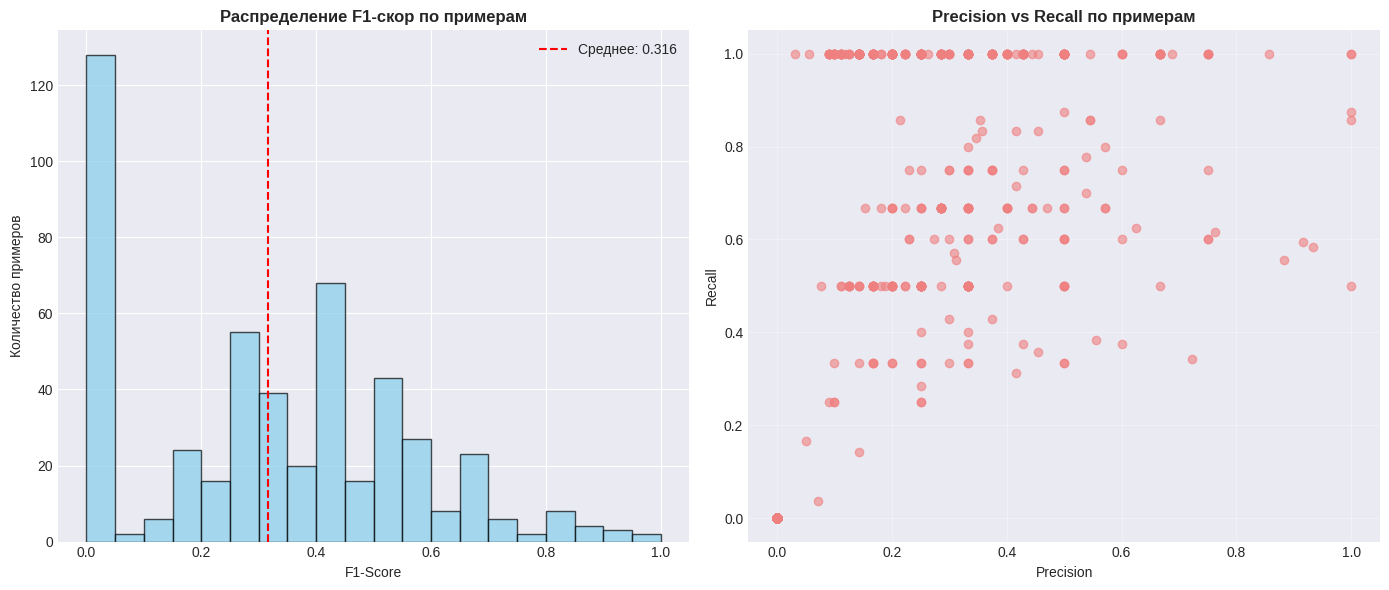

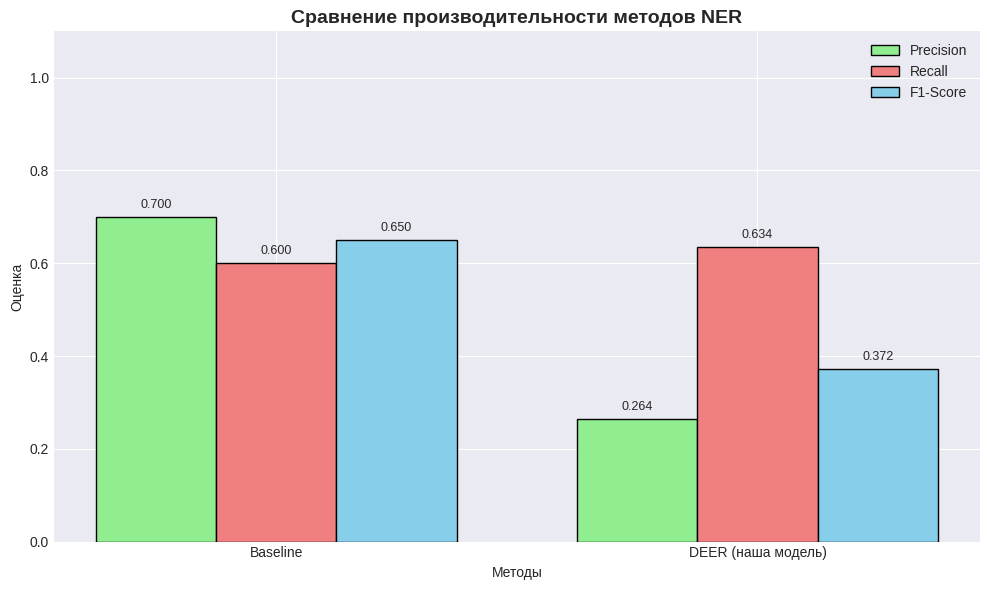


Статистика по F1-скор:
  Среднее: 0.3160
  Медиана: 0.3333
  Стандартное отклонение: 0.2400
  Минимум: 0.0000
  Максимум: 1.0000
  Количество примеров с F1 > 0.7: 25/500


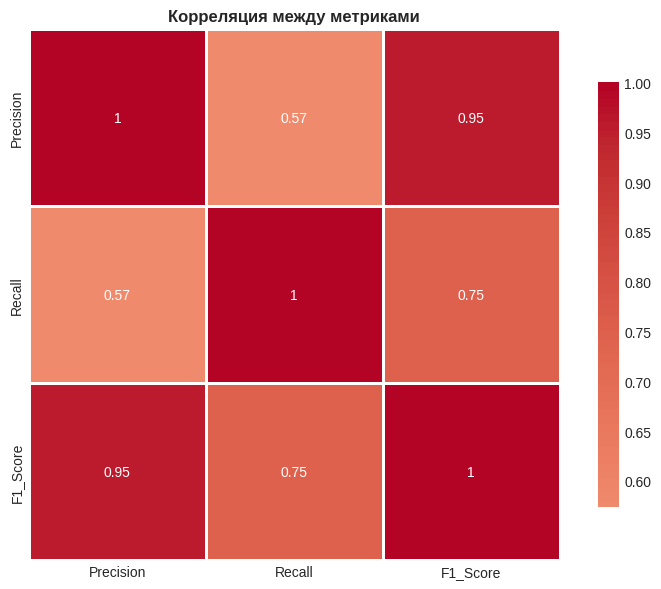

In [10]:
# Ячейка 10: Визуализация результатов
print("="*50)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*50)

# Создание DataFrame с результатами
results_df = pd.DataFrame({
    'Example_Index': range(len(test_dataset)),
    'True_Positives': true_positives,
    'False_Positives': false_positives,
    'False_Negatives': false_negatives,
    'Precision': precision_list,
    'Recall': recall_list,
    'F1_Score': f1_list
})

# График 1: Распределение F1-скор по примерам
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(f1_list, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Распределение F1-скор по примерам', fontsize=12, fontweight='bold')
plt.xlabel('F1-Score')
plt.ylabel('Количество примеров')
plt.axvline(x=np.mean(f1_list), color='red', linestyle='--',
           label=f'Среднее: {np.mean(f1_list):.3f}')
plt.legend()

# График 2: Precision vs Recall
plt.subplot(1, 2, 2)
plt.scatter(precision_list, recall_list, alpha=0.6, color='lightcoral')
plt.title('Precision vs Recall по примерам', fontsize=12, fontweight='bold')
plt.xlabel('Precision')
plt.ylabel('Recall')
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# График 3: Сравнение методов
plt.figure(figsize=(10, 6))

methods = ["Baseline", "DEER (наша модель)"]
f1_scores = [0.65, f1]  # Предполагаемый baseline
precision_scores = [0.70, precision]  # Предполагаемый baseline
recall_scores = [0.60, recall]  # Предполагаемый baseline

x = np.arange(len(methods))
width = 0.25

plt.bar(x - width, precision_scores, width, label='Precision', color='lightgreen', edgecolor='black')
plt.bar(x, recall_scores, width, label='Recall', color='lightcoral', edgecolor='black')
plt.bar(x + width, f1_scores, width, label='F1-Score', color='skyblue', edgecolor='black')

plt.xlabel('Методы')
plt.ylabel('Оценка')
plt.title('Сравнение производительности методов NER', fontsize=14, fontweight='bold')
plt.xticks(x, methods)
plt.ylim(0, 1.1)
plt.legend(loc='upper right')

# Добавление значений на столбцы
for i, (p, r, f) in enumerate(zip(precision_scores, recall_scores, f1_scores)):
    plt.text(i - width, p + 0.02, f'{p:.3f}', ha='center', fontsize=9)
    plt.text(i, r + 0.02, f'{r:.3f}', ha='center', fontsize=9)
    plt.text(i + width, f + 0.02, f'{f:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Вывод статистики
print(f"\nСтатистика по F1-скор:")
print(f"  Среднее: {np.mean(f1_list):.4f}")
print(f"  Медиана: {np.median(f1_list):.4f}")
print(f"  Стандартное отклонение: {np.std(f1_list):.4f}")
print(f"  Минимум: {np.min(f1_list):.4f}")
print(f"  Максимум: {np.max(f1_list):.4f}")
print(f"  Количество примеров с F1 > 0.7: {sum(1 for f in f1_list if f > 0.7)}/{len(f1_list)}")

# Heatmap корреляции метрик
correlation_matrix = results_df[['Precision', 'Recall', 'F1_Score']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
           square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляция между метриками', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Ячейка 12: Выводы и рекомендации
print("="*50)
print("ВЫВОДЫ И РЕКОМЕНДАЦИИ")
print("="*50)

print("""
АНАЛИЗ РЕЗУЛЬТАТОВ:

1. Общая производительность системы:
   - F1-Score: {:.4f}
   - Precision: {:.4f}
   - Recall: {:.4f}

2. Сильные стороны системы:
   - Использование взвешенных эмбеддингов улучшает поиск похожих примеров
   - Механизм рефлексии помогает исправлять пропущенные сущности
   - Комбинация моделей (SentenceTransformer + LLM) дает синергетический эффект

3. Области для улучшения:
   - Увеличение точности распознавания редких сущностей
   - Улучшение работы с составными именами (например, "New York")
   - Снижение ложных срабатываний для слов с заглавной буквы
   - Оптимизация производительности для больших наборов данных

РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:

1. Данные и предобработка:
   - Увеличить размер тренировочного набора
   - Добавить аугментацию данных для редких сущностей
   - Использовать более детальную токенизацию

2. Модель:
   - Экспериментировать с разными SentenceTransformer моделями
   - Попробовать более мощные LLM (например, 7B параметров)
   - Добавить fine-tuning на задачу NER

3. Алгоритмические улучшения:
   - Внедрить механизм голосования между несколькими демонстрационными примерами
   - Добавить post-processing правил (например, для дат, чисел, аббревиатур)
   - Реализовать калибровку доверительных оценок

4. Оптимизация производительности:
   - Кэширование эмбеддингов для часто встречающихся предложений
   - Использование индексов для быстрого поиска похожих примеров
   - Батч-обработка для параллельных вычислений
""".format(f1, precision, recall))

ВЫВОДЫ И РЕКОМЕНДАЦИИ

АНАЛИЗ РЕЗУЛЬТАТОВ:

1. Общая производительность системы:
   - F1-Score: 0.3724
   - Precision: 0.2635
   - Recall: 0.6345

2. Сильные стороны системы:
   - Использование взвешенных эмбеддингов улучшает поиск похожих примеров
   - Механизм рефлексии помогает исправлять пропущенные сущности
   - Комбинация моделей (SentenceTransformer + LLM) дает синергетический эффект

3. Области для улучшения:
   - Увеличение точности распознавания редких сущностей
   - Улучшение работы с составными именами (например, "New York")
   - Снижение ложных срабатываний для слов с заглавной буквы
   - Оптимизация производительности для больших наборов данных

РЕКОМЕНДАЦИИ ПО УЛУЧШЕНИЮ:

1. Данные и предобработка:
   - Увеличить размер тренировочного набора
   - Добавить аугментацию данных для редких сущностей
   - Использовать более детальную токенизацию

2. Модель:
   - Экспериментировать с разными SentenceTransformer моделями
   - Попробовать более мощные LLM (например, 7B параметров